In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/project/initialization_shock/data/'
from matplotlib.patches import Rectangle

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
ME416=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0416/holding/geosgcm_surf/200504/*surf*2005041*z.nc4')
ME421=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0421/holding/geosgcm_surf/200504/*surf*2005042*z.nc4')
ME426=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0426/holding/geosgcm_surf/200504/*surf*2005042*z.nc4')
#ME501=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0501/holding/geosgcm_surf/200505/*surf*2005050*z.nc4')
ME506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*2005050*z.nc4')
ME511=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_ME0511/holding/geosgcm_surf/200505/*surf*2005051*z.nc4')


In [4]:
RP416=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0416/holding/geosgcm_surf/200504/*surf*2005041*z.nc4')
RP421=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0421/holding/geosgcm_surf/200504/*surf*2005042*z.nc4')
RP426=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0426/holding/geosgcm_surf/200504/*surf*2005042*z.nc4')
#RP501=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0501/holding/geosgcm_surf/200505/*surf*2005050*z.nc4')
RP506=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0506/holding/geosgcm_surf/200505/*surf*2005050*z.nc4')
RP511=xr.open_mfdataset('/nobackupp27/afahad/exp/IAU_exp/GEOSMIT_RP0511/holding/geosgcm_surf/200505/*surf*2005051*z.nc4')


In [5]:
# METS=(ME416.TS[:16,:,:]+ME421.TS.data[:16,:,:]+ME426.TS.data[:16,:,:]+ME506.TS.data[:16,:,:]+ME511.TS.data[:16,:,:]).compute()
# RPTS=(RP416.TS[:16,:,:]+RP421.TS.data[:16,:,:]+RP426.TS.data[:16,:,:]+RP506.TS.data[:16,:,:]+RP511.TS.data[:16,:,:]).compute()

In [6]:
METS_FOUND=(ME416.TS_FOUND[:16,:,:]+ME421.TS_FOUND.data[:16,:,:]+ME426.TS_FOUND.data[:16,:,:]+ME506.TS_FOUND.data[:16,:,:]+ME511.TS_FOUND.data[:16,:,:]).compute()
RPTS_FOUND=(RP416.TS_FOUND[:16,:,:]+RP421.TS_FOUND.data[:16,:,:]+RP426.TS_FOUND.data[:16,:,:]+RP506.TS_FOUND.data[:16,:,:]+RP511.TS_FOUND.data[:16,:,:]).compute()

In [7]:
METS=METS_FOUND/5
RPTS=RPTS_FOUND/5

In [9]:
# META=(ME416.TA[:16,:,:]+ME421.TA.data[:16,:,:]+ME426.TA.data[:16,:,:]+ME506.TA.data[:16,:,:]+ME511.TA.data[:16,:,:]).compute()
# RPTA=(RP416.TA[:16,:,:]+RP421.TA.data[:16,:,:]+RP426.TA.data[:16,:,:]+RP506.TA.data[:16,:,:]+RP511.TA.data[:16,:,:]).compute()

In [10]:
# META=META/5
# RPTA=RPTA/5

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

def plot_xr(data_array, lon, lat, ax=None, **kwargs):
    """
    Creates a map plot for an xarray DataArray using Cartopy.
    This function is optimized for speed using pcolormesh and is
    compatible with subplots.

    Args:
        data_array (xr.DataArray): The 2D xarray DataArray to plot.
        lon (xr.DataArray or np.ndarray): 1D or 2D array of longitude values.
        lat (xr.DataArray or np.ndarray): 1D or 2D array of latitude values.
        ax (matplotlib.axes.Axes, optional): The axes object to plot on.
                                             If None, a new figure and axes are created.
                                             Default: None.
        **kwargs: Optional keyword arguments for customization.
            projection_style (str): 'mercator', 'robinson', 'mollweide', 'orthographic'.
                                    Default: 'mercator'.
            cmap (str or Colormap): The colormap for the plot. Default: 'viridis'.
            levels (list or int): A list of discrete levels for color mapping.
                                  Required for discrete colorbars. Default: 11.
            title (str): The title for the plot. Default: ''.
            cbar_label (str): The label for the colorbar. Default: ''.
            add_coastlines (bool): Whether to add coastlines. Default: True.
            add_borders (bool): Whether to add country borders. Default: False.
            add_land (bool): Whether to add a land mask. Default: False.
            add_gridlines (bool): Whether to add gridlines. Default: True.
            central_longitude (float): The central longitude for the projection. Default: 0.
            central_latitude (float): The central latitude for 'orthographic'. Default: 0.
    """
    # --- 1. Deconstruct keyword arguments ---
    projection_style = kwargs.get('projection_style', 'mercator').lower()
    central_longitude = kwargs.get('central_longitude', 0)
    central_latitude = kwargs.get('central_latitude', 0)
    cmap = kwargs.get('cmap', 'viridis')
    levels = kwargs.get('levels', 11)
    title = kwargs.get('title', 'Cartopy Plot')
    cbar_label = kwargs.get('cbar_label', '')
    add_coastlines = kwargs.get('add_coastlines', True)
    add_borders = kwargs.get('add_borders', False)
    add_land = kwargs.get('add_land', False)
    add_gridlines = kwargs.get('add_gridlines', True)

    # --- 2. Select the map projection ---
    proj_map = {
        'robinson': ccrs.Robinson,
        'mercator': ccrs.Mercator,
        'mollweide': ccrs.Mollweide,
        'orthographic': ccrs.Orthographic
    }
    proj_class = proj_map.get(projection_style, ccrs.Mercator)
    if projection_style == 'orthographic':
        projection = proj_class(central_longitude=central_longitude, central_latitude=central_latitude)
    else:
        projection = proj_class(central_longitude=central_longitude)

    # --- 3. Handle Axes for Subplot Compatibility ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': projection})
    else:
        fig = ax.get_figure()

    # --- 4. Plot the data using pcolormesh for performance ---
    norm = None
    if isinstance(levels, (list, np.ndarray)):
        # Get a colormap object with the correct number of colors
        cmap_obj = plt.get_cmap(cmap, len(levels) - 1)
        # Create a BoundaryNorm for discrete color mapping
        norm = BoundaryNorm(levels, ncolors=cmap_obj.N, clip=True)
    else:
        cmap_obj = plt.get_cmap(cmap)

#     im = ax.pcolormesh(
#         lon, lat, data_array,
#         cmap=cmap_obj,
#         norm=norm,
#         transform=ccrs.PlateCarree()
#     )
    im = ax.contourf(
        lon, lat, data_array,
        cmap=cmap_obj,
        norm=norm,
        transform=ccrs.PlateCarree(),
        levels=levels,
        extend='both'
    )

    # --- 5. Add geographic features ---
    if add_land:
        ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k', facecolor='beige')
    if add_coastlines:
        ax.add_feature(cfeature.COASTLINE)
    if add_borders:
        ax.add_feature(cfeature.BORDERS, linestyle=':')
    if add_gridlines:
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False

    # --- 6. Add colorbar and title ---
    # Create the colorbar on the figure to avoid subplot size issues
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.02, shrink=0.8)
    if isinstance(levels, (list, np.ndarray)):
        cbar.set_ticks(levels)
    cbar.set_label(cbar_label, fontsize=12)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_global()

In [9]:
METS=METS.resample(time="1D").mean()
RPTS=RPTS.resample(time="1D").mean()


In [10]:
METS1=METS.copy()
METS=METS.where(np.abs(METS['lat']) <= 60, 0)
RPTS=RPTS.where(np.abs(METS['lat']) <= 60, 0)

/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:825: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:836: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  line_strings = list(multi_line_string)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:836: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geome

/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:982: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  line_strings.extend(multi_line_string)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/crs.py:982: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  line_strings.extend(multi_line_string)
/nobackup/gmao_SIteam/GEOSpyD/4.11.0_py3.9/2022-04-28/lib/python3.9/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of 

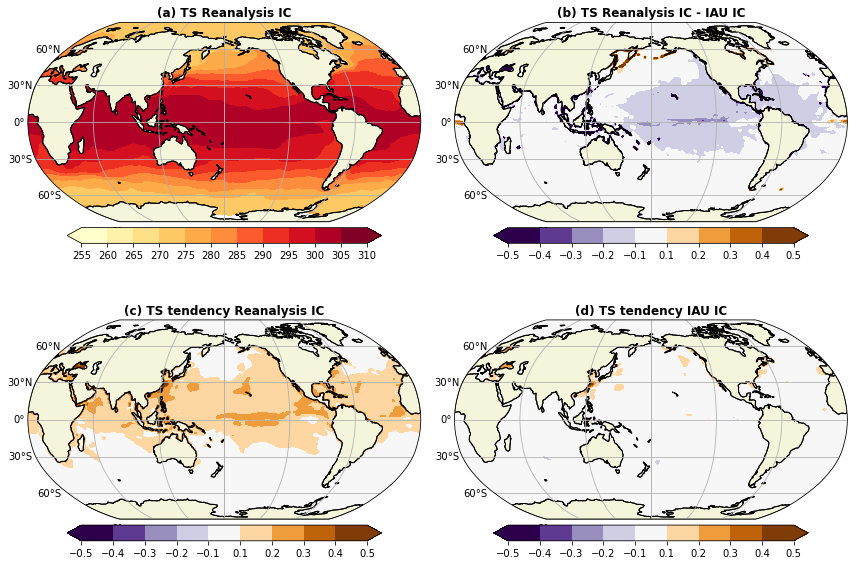

In [11]:
fig, axes = plt.subplots(
        2, 2,
        figsize=(12, 8.5),
        subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}
    )
axes_flat = axes.flatten()

plot_xr(
            METS1[0,:,:],
            ME506.lon,
            ME506.lat,
            levels=arange(255,311,5),
            projection_style='robinson',
            cmap='YlOrRd',
            title='(a) TS Reanalysis IC',
            ax=axes_flat[0],
            add_gridlines=True, 
            central_longitude=180,
            add_land=True
        )

plot_xr(
            METS[0,:,:]-RPTS[0,:,:],
            ME506.lon,
            ME506.lat,

            projection_style='robinson',
            cmap='PuOr_r',
            levels=array([-.5,-.4,-.3,-.2,-.1,.1,.2,.3,.4,.5]),
            title='(b) TS Reanalysis IC - IAU IC',
            ax=axes_flat[1],
            add_gridlines=True, 
            central_longitude=180,
            add_land=True
        )


plot_xr(
            METS[1,:,:]-METS[0,:,:],
            ME506.lon,
            ME506.lat,

            projection_style='robinson',
            cmap='PuOr_r',
            levels=array([-.5,-.4,-.3,-.2,-.1,.1,.2,.3,.4,.5]),
            title='(c) TS tendency Reanalysis IC',
            ax=axes_flat[2],
            add_gridlines=True, 
            central_longitude=180,
            add_land=True
        )

plot_xr(
            RPTS[1,:,:]-RPTS[0,:,:],
            ME506.lon,
            ME506.lat,

            projection_style='robinson',
            cmap='PuOr_r',
            levels=array([-.5,-.4,-.3,-.2,-.1,.1,.2,.3,.4,.5]),
            title='(d) TS tendency IAU IC',
            ax=axes_flat[3],
            add_gridlines=True, 
            central_longitude=180,
            add_land=True
        )


plt.tight_layout()
plt.savefig('SST_tend.png',dpi=200)